# Fundamental Programming for Geospatial Data Analysis
## Machine Learning
### Introduction to exploratory data analysis

#### M. Khodadadzadeh
*version: Oct 2025*

## Introduction
This document shows examples on data exploration in Python. It starts with inspecting the dimensionality,structure and data of a Pandas DataFrame object, followed by basic statistics and various charts like pie charts and histograms. Exploration of multiple variables are then demonstrated, including grouped distribution, grouped boxplots, scattered plot. It also shows how to save figures and charts. 
You should have a basic knowledge of: 
- python basics
- pandas
- matplotlib

### Pandas
For this tutorial you are going to use the Pandas library. Pandas is a Python library which provides high-performance and easy-to-use data structures. It is used for data manipulation, analysis and cleaning.

Complete Pandas documentation available at: https://pandas.pydata.org/pandas-docs/stable/index.html

### Matplotlib
Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. 

See the following link for more information: https://matplotlib.org/


## Loading Data and checking the main characteristics 

### Setting the environment

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix 
import matplotlib.pyplot as plt
%matplotlib inline 
# When using the 'inline' backend, your matplotlib graphs will be included in your notebook, next to the code.

### Reading Iris data 
https://archive.ics.uci.edu/ml/datasets/iris


The iris data is used in this tutorial for demonstration of data exploration in Python. The data set contains **3 species** (i.e., classes) of **50 instances each**, where each class refers to a type of iris plant. Attribute Information: 
1. **sepal length**(*cm*)
2. **sepal width**(*cm*)
3. **petal length**(*cm*)
4. **petal width**(*cm*)
5. **species**(*Iris-setosa*, *Iris-versicolor*, and *Iris-virginica*)

In [2]:
# Reading a csv file using pandas
df = pd.read_csv('IrisData.csv')

# # Alternatively you can read the Iris data set from the following location:
# # Location of dataset
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# # Assign colum names to the dataset
# names = ['sepal_length','sepal_width','petal_length','petal_width','species']

# # Read dataset to pandas dataframe
# df = pd.read_csv(url, names=names)

In [3]:
# This prints a formatted table
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
# You can also use print() function
print(df)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


Now, let's check the first and the last three rows of data using slicing. The first or last rows of 
data can also be retrieved with DataFrame.head()or DataFrame.tail() 

In [5]:
# Get only the first 3 rows, this is the same as df[0:3] (last index is not comprised in the slice)
df[:3]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [6]:
# The df.head() by default will return 3 rows
df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [7]:
# Get only the last 3 rows, this is the same as df[-3:150] or df[147:150]
df[-3:]

,sepal_length,sepal_width,petal_length,petal_width,species
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [8]:
# The df.tail() by default will return 3 rows
df.tail(3)

,sepal_length,sepal_width,petal_length,petal_width,species
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [9]:
# This prints information about the df including the index dtype and columns, non-null values and memory usage.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
# get only the shape of the dataframe
df.shape

(150, 5)

In [11]:
# get a list with the names of the columns
list(df.columns)

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [12]:
# get the type of each column
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

## Exploring individual variables

The DataFrame.describe() returns  various  summary statistics for each column including: 
- number of rows
- mean value
- std value
- min value
- max value
- first quartile
- second quartile
- third quartile

In [13]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The  mean,  median,  min,  max,  median,  mode,  std,  variance,  and  quantile  can  also be obtained with functions. For example: 
- DataFrame.mean()
- DataFrame.median()
- DataFrame.min()

In [14]:
# pass 0 to calculate the columns mean; pass 1 to calculate the rows mean; 0 is the default
# we first drop the 'species' column since it is object
df.drop(columns=['species']).mean(axis = 0)
# df.drop(columns=['species']).median(axis = 0)
# df.drop(columns=['species']).mode(axis = 0)
# df.drop(columns=['species']).std(axis = 0)
# df.drop(columns=['species']).min(axis = 0)
# df.drop(columns=['species']).max(axis = 0)

sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64

In [15]:
df.drop(columns=['species']).quantile([0,0.25,0.5,0.75,1])

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


We can also retrieve the values of a single column (which is a Pandas Series). To get values for a single column we use the index:

In [16]:
df['sepal_length'].var()
# or
df.sepal_length.var()

0.6856935123042505

Or for example, the first 4 values of *sepal length* column can be fetched with the code below: 

In [17]:
df['sepal_length'][:4]
# or
df.sepal_length[:4]

0    5.1
1    4.9
2    4.7
3    4.6
Name: sepal_length, dtype: float64

Now, let's get a list with the unique names in the species column. Remember the type of this column is object.

In [18]:
# get a list with the unique names in the species column which is object
list(df['species'].unique())
# or
list(df.species.unique())

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

We can check a distribution with histogram and density using DataFrame.hist() and DataFrame.plot().

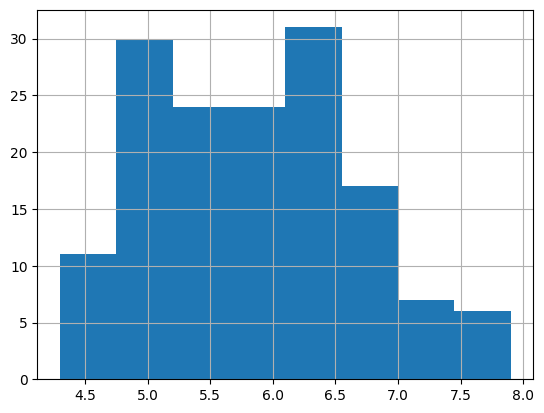

In [19]:
df['sepal_length'].hist(bins=8)
plt.show() ## I need it to show the plot 

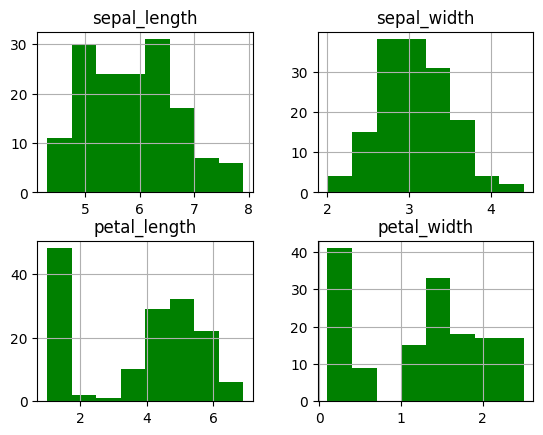

In [20]:
df.hist(bins=8,color='g')
plt.show()

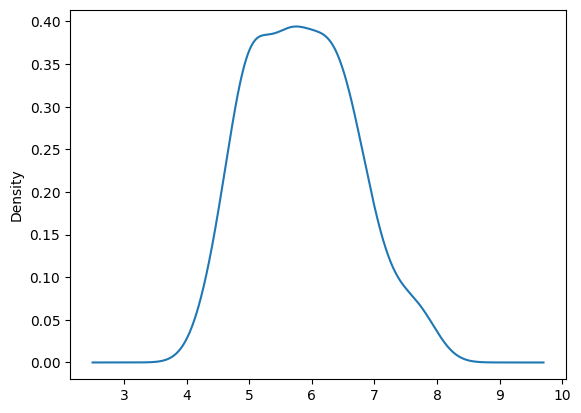

In [21]:
df['sepal_length'].plot(kind='kde')
plt.show()

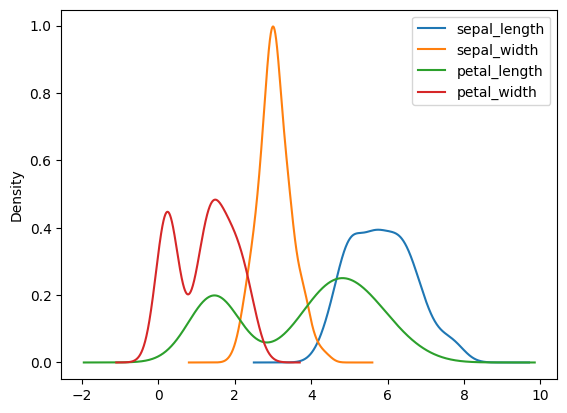

In [22]:
df.plot(kind='kde')
plt.show()

The frequency of factors can be calculated after grouping data  with DataFrame.groupby(), and then plotted as a pie chart or a bar chart with Series.plot() 

In [23]:
#here we get a Pandas.Series with the size for each species
counts = df['sepal_length'].groupby(df['species']).size() 
counts

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: sepal_length, dtype: int64

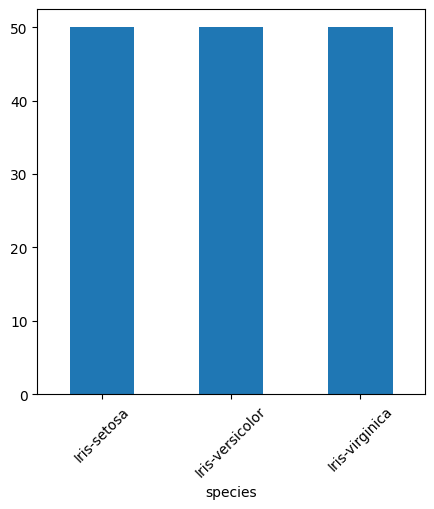

In [24]:
counts.plot(kind='bar',figsize=(5,5), rot=45)
plt.show()

In [25]:
df.drop(columns=['species']).cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.039268,1.273682,0.516904
sepal_width,-0.039268,0.188004,-0.321713,-0.117981
petal_length,1.273682,-0.321713,3.113179,1.296387
petal_width,0.516904,-0.117981,1.296387,0.582414


In [26]:
df.drop(columns=['species']).corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [27]:
#  the stats of 'sepal length' of every species
a = df['sepal_length'].groupby(df['species']).describe()
print (a)

                 count   mean       std  min    25%  50%  75%  max
species                                                           
Iris-setosa       50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8
Iris-versicolor   50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0
Iris-virginica    50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9


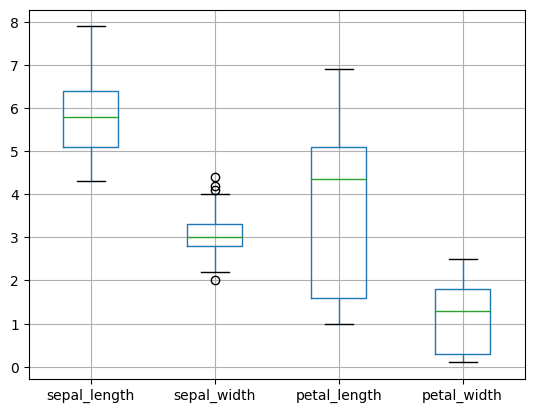

In [28]:
# Boxplot of all the numerical variables
ax = df.boxplot()
ax.get_figure().savefig('boxplot.png')

## Bi-Variate Analysis

/usr/local/lib/python3.8/dist-packages/pandas/plotting/_matplotlib/core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


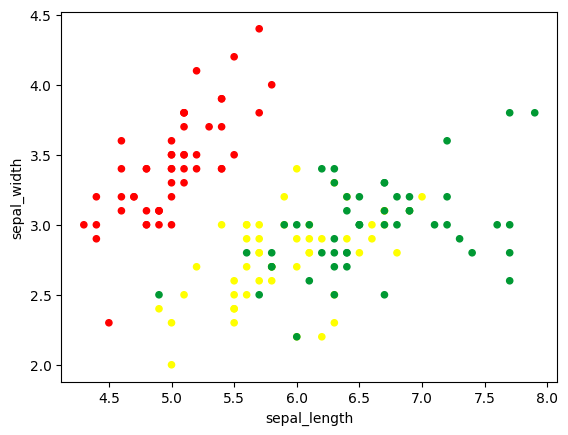

In [29]:
# Scatter plot of two variables considering their categories
indexes = df['species']
species = list(df['species'].unique())
color_set = ('#FF0000', '#FFFF00', '#009933')
color_list = [color_set[species.index(label)] for label in indexes]
ax = df.plot(kind='scatter',x='sepal_length',y='sepal_width', c = color_list)
ax.get_figure().savefig('sepal_length_vs_sepal_width.png')

<Figure size 640x480 with 0 Axes>

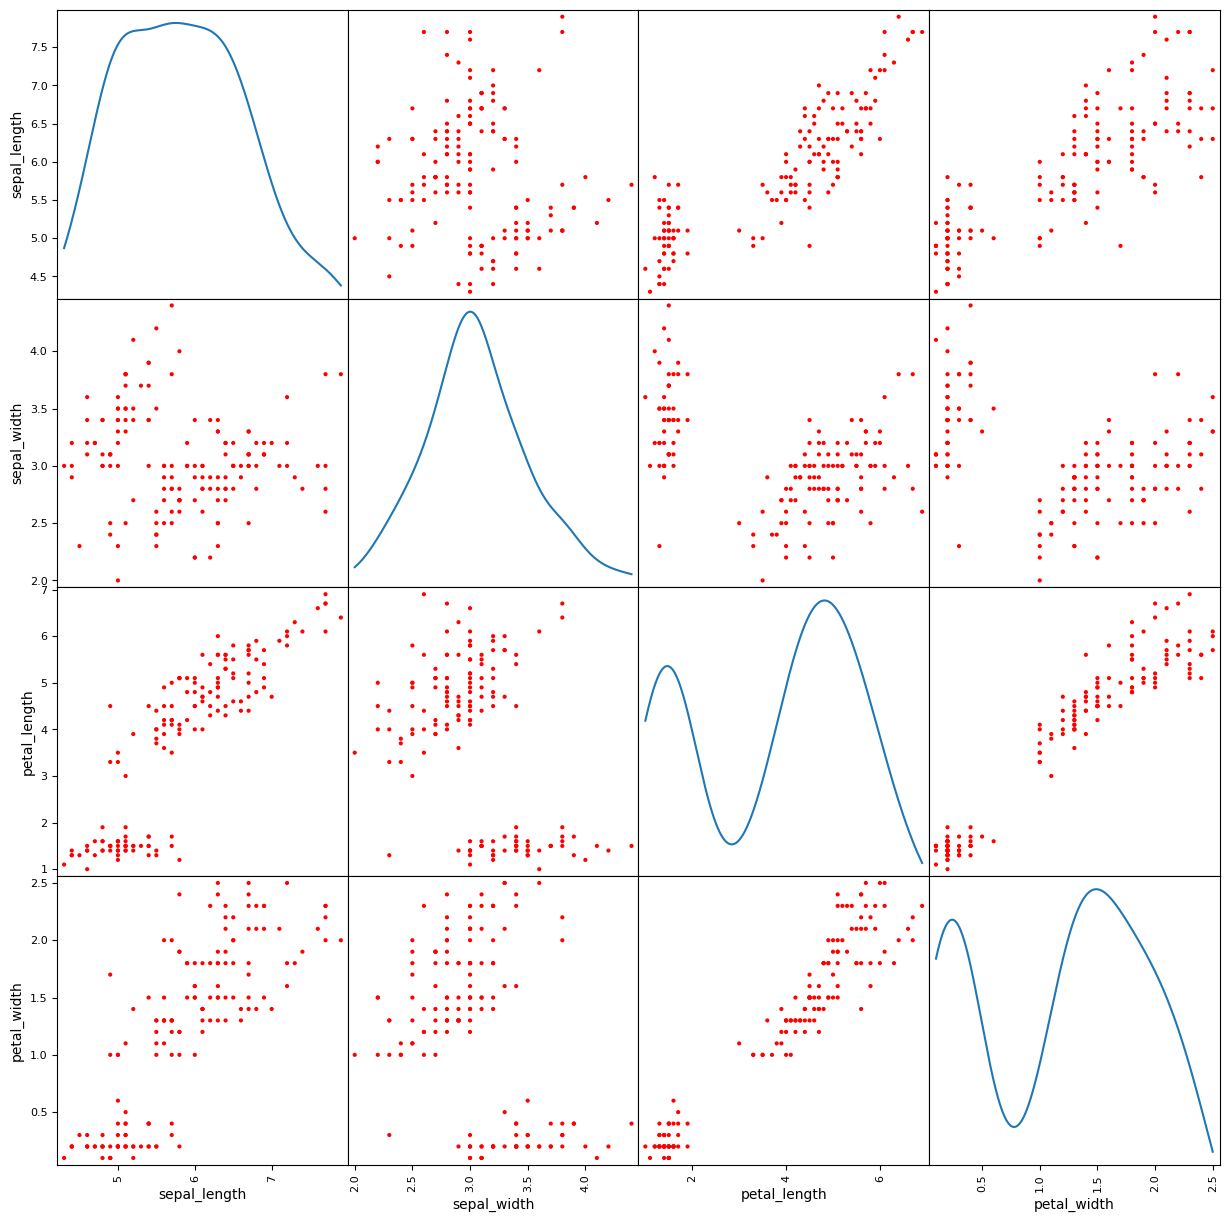

In [30]:
# Drawing a matrix of scatter plots
plt.figure()
scatter_matrix(df,alpha=1, figsize=(15,15),diagonal='kde',c='r')
plt.savefig('scatter_mat.png')

## Additional Questions

Can you come up with some other exploratory analyses?